In [1]:
import numpy as np  # import numerical python
import matplotlib.pyplot as plt  # import plotting functions
import seaborn as sns  # import nicer plotting functions
import pandas as pd
import polars as pl
import tifffile as tiff
from tifffile import imwrite, imread
from copy import deepcopy
import os
import time
from sklearn.cluster import DBSCAN, HDBSCAN
from copy import copy
import sys

sys.path.append("../..")

from src import IOFunctions

IO = IOFunctions.IO_Functions()

from src import Multicolour_Simulation_Functions

MSF = Multicolour_Simulation_Functions.MultiC_Sim_Funcs()

from src import PlottingFunctions

plotter = PlottingFunctions.Plotter(dark_background=False)

from src import ImageAnalysisFunctions

I_AF = ImageAnalysisFunctions.Image_Analysis_Functions()

from src import sCMOSFunctions

sCMOS = sCMOSFunctions.sCMOS_Functions()

from src import PSFFunctions

PSF = PSFFunctions.PSF_Functions()

from src import SpectralFunctions

S_F = SpectralFunctions.Spectral_Funcs()

from src import MaskFunctions

M_F = MaskFunctions.Mask_Functions()

from src import SpotDetectionFunctions

SD_F = SpotDetectionFunctions.SpotDetection_Functions()

from src import SR_Functions

SRes_F = SR_Functions.SuperRes_Functions()

from src import HelperFunctions

import DriftCorrectionFunctions as DCF
drift_corrector = DCF.Drift_Correction_Functions()


H_F = HelperFunctions.Helper_Functions()

from src import FiducialDetection

FD = FiducialDetection.FiducialDetector()

from src import render
from src import postprocess as _postprocess
from src.LinkingFunctions import link_localisations

import types

smoothing_function = types.SimpleNamespace()
smoothing_function.args = {"sigma": 1.5}
smoothing_function.extent = 1.5
smoothing_function.smoothing_function = sCMOS.gaussian_filter_stack
smoothing_function.data_arg = "image"

def fwhm(sigma):
    return 2*np.sqrt(2*np.log(2))*sigma

INFO:Constants:Logging to file: /home/jsb92/Documents/pyBayerSMLM/logs/Constants_20260318_094615.log
/tmp/ipykernel_1669572/3904180148.py:27: DeprecationWarning: PlottingFunctions.Plotter is deprecated and will be removed in a future version. Use PlottingBase.PublicationPlotter directly instead.
  plotter = PlottingFunctions.Plotter(dark_background=False)


In [2]:
data_folder = "../../Camera_Calibrations/Ximea_Camera"
gain_map = IO.read_tiff(os.path.join(data_folder, "gain.tif"))
offset_map = IO.read_tiff(os.path.join(data_folder, "offset.tif"))
variance = IO.read_tiff(os.path.join(data_folder, "variance.tif"))
read_noise = IO.read_tiff(os.path.join(data_folder, "readnoise.tif"))
rqe = IO.read_tiff(os.path.join(data_folder, "rqe.tif"))
R, G, B, wavelength = S_F.getpixelefficiency()

pixel_QYs = np.vstack([B, G, R])
camera_parameters = {}
camera_parameters["pixel_QYs"] = pixel_QYs
camera_parameters["pixel_order"] = ["B", "G", "R"]
camera_parameters["pixel_order_indices"] = [0, 1, 2]

In [3]:
data_folder = '/scratch/sycamore-asap/2026_Multicolour_Paper/Data/Ximea/HeLaCellSTORM/20250523_HeLa_STORM/Cell4_HILO_190mW_638_ximea638_setting/Lp638_190_mw_40ms_exosure_HILO_1'

In [4]:
tif_files = H_F.file_search(data_folder, ".tif", "")
metadata_files = H_F.file_search(data_folder, "metadata", "")

In [5]:
localisation_files = H_F.file_search(data_folder, ".h5", "")

In [6]:
loc_data = pd.read_hdf(localisation_files[0])

In [7]:
x_coord, y_coord, width, height = IO.metadata_reader_imageJ(metadata_files[0])
n_frames = IO.metadata_nframes_reader_imageJ(metadata_files[0])

In [8]:
loc_data = loc_data[loc_data["xc_err"] < 30/69]
loc_data = loc_data[loc_data["yc_err"] < 30/69]

loc_data = loc_data[loc_data["xc_err"] > 0]
loc_data = loc_data[loc_data["yc_err"] > 0]

loc_data = loc_data[loc_data["s_x_err"] < 30/69]
loc_data = loc_data[loc_data["s_y_err"] < 30/69]

loc_data = loc_data[(loc_data["s_x"] > 100/69) & (loc_data["s_x"] < 175/69)]
loc_data = loc_data[(loc_data["s_y"] > 100/69) & (loc_data["s_y"] < 175/69)]

loc_data = loc_data[loc_data["A_B_err"] < 0.01]
loc_data = loc_data[loc_data["A_G_err"] < 0.01]
loc_data = loc_data[loc_data["A_R_err"] < 0.01]

loc_data = loc_data[loc_data["A_B"] > 0.005]
loc_data = loc_data[loc_data["A_G"] > 0.05]
loc_data = loc_data[loc_data["A_R"] > 0.5]

loc_data = loc_data[loc_data["bg_B_err"] < 0.15]
loc_data = loc_data[loc_data["bg_G_err"] < 0.15]
loc_data = loc_data[loc_data["bg_R_err"] < 0.15]

loc_data = loc_data[~((loc_data['spot_snr'] < 2) & (loc_data['photons'] < 500) & (loc_data['spot_matched_filter_response'] < 100))]

loc_data = loc_data[loc_data["spot_background_std"] > 10]

#loc_data = loc_data[loc_data["photons"] < 100000]
#loc_data = loc_data[loc_data["photons"] > 100]


loc_data = loc_data[loc_data["chi_sqr"] < 1.5]

In [ ]:
drift_corrector = DCF.Drift_Correction_Functions()

info = [{
    "Width": width,         # Image width in pixels
    "Height": height,        # Image height in pixels
    "Frames": np.max(loc_data['frame']),      # Total number of frames in the movie
    "Pixelsize": 69,        # pixel size always in nm
}]

corrected_locs, drift_result = drift_corrector.undrift(locs=loc_data.to_records(index=False),
                                          info=info,
                                          method="aim",
                                          segmentation=20,
                                            intersect_d=20/69,
                                          roi_r=60/69,
                                         )
corrected_locs = pd.DataFrame(corrected_locs)

AIM Undrifting (1/2):   9%|█▌                | 222/2499 [00:01<00:23, 97.85it/s]

In [ ]:
plt.plot(drift_result.drift_x*69)
plt.plot(drift_result.drift_y*69)

plt.show()

In [ ]:
link_r = 0.5 * (np.median(corrected_locs['xc_err']) + np.median(corrected_locs['yc_err']))
linked = link_localisations(corrected_locs, n_frames=n_frames, r_max=link_r, max_dark_time=2)

In [ ]:
image = render.render(
    locs=linked.to_records(index=False),
    oversampling=1,
    viewport=((0, 0), (height, width)),
    blur_method="smooth",
)[1]

In [ ]:
region_centers, binary_mask, threshold, metadata = drift_corrector.detect_high_density_regions_from_image(
      smoothed_image=image,
      histogram_bins=821,
      threshold_percentile=99.9,
      pixelsize=69.0,
      title="Fiducial Detection"
  )

In [ ]:
info = [{
    "Width": width,         # Image width in pixels
    "Height": height,        # Image height in pixels
    "Frames": np.max(linked['frame']),      # Total number of frames in the movie
    "Pixelsize": 69,        # pixel size always in nm
}]

selected_puncta, selection_metadata = drift_corrector.select_puncta_from_regions(
        locs=linked.to_records(index=False),                             # Your localization data
        region_centres=region_centers,         # Output from Step 1
        binary_mask=binary_mask,               # Output from Step 1
        pixelsize=info[0]['Pixelsize'],
        selection_box_size_nm=500.0,         # Box size around each region center (adjust as needed)
        min_localisations_per_region=int(0.5*info[0]['Frames']),      # Minimum locs for valid fiducial (adjust as needed)
        title="Step 2: Puncta Selection",
        create_plot=True
    )

In [ ]:
linked_fremoved = FD.remove_puncta_locs(linked.to_records(index=False), selected_puncta)
linked_fremoved = pd.DataFrame(linked_fremoved)

In [31]:
oversampling=8
image_nofid = render.render(
    locs=linked_fremoved.to_records(index=False),
    oversampling=oversampling,
    viewport=((0, 0), (height, width)),
    blur_method="gaussian",
)[1]

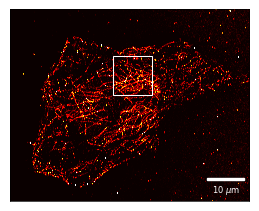

In [32]:
fig, axs = plotter.one_column_plot(height=2)

axs = plotter.image_plot(
    axs=axs,
    data=image_nofid[300:-300, 800:-2000],
    vmin=np.percentile(image_nofid, 1),
    vmax=np.percentile(image_nofid, 99.5),
    cbar="off",
    cbarlabel="localisations",
    pixelsize=69 / oversampling,
    scalebarsize=10000,
    scalebarlabel=r"10 $\mu$m",
    cmap="hot",
)

import matplotlib.patches as patches

rect = patches.Rectangle(
    ((500 * oversampling) - 800, (450 * oversampling) - 300),
    150 * oversampling,
    150 * oversampling,
    linewidth=0.75,
    edgecolor="white",
    facecolor="none",
)

# Add the patch to the Axes
axs.add_patch(rect)

#[300:-300, 800:-2000]

plt.savefig("Exemplar_SuperRes_Box.svg", dpi=600, format="svg")
plt.show()

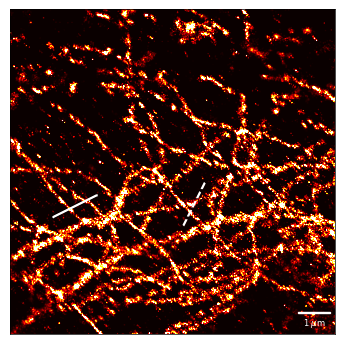

In [33]:
fig, axs = plotter.one_column_plot()

data = image_nofid[
        int(450 * oversampling) : int(450 * oversampling) + int(150 * oversampling),
        int(500) * oversampling : int(500) * oversampling + int(150 * oversampling),
    ]

axs = plotter.image_plot(
    axs=axs,
    data=data,
    vmin=np.percentile(image_nofid, 1),
    vmax=np.percentile(image_nofid, 99.5),
    cbar="off",
    cbarlabel="localisations",
    pixelsize=69 / oversampling,
    scalebarsize=1000,
    scalebarlabel=r"1 $\mu$m",
    cmap="hot",
)

from skimage.draw import line as bresenham_line

r0, c0 = oversampling*54, oversampling*20    # row, col of p0                                                                                                                                       
r1, c1 = oversampling*64, oversampling*40  # row, col of p1
rows_1, cols_1 = bresenham_line(r0, c0, r1, c1)
values_1 = data[rows_1, cols_1]
# Coordinates of the line we'd like to sample along

axs.plot(cols_1, rows_1, color='white', linewidth=1.5)

r0, c0 = oversampling*50, oversampling*80    # row, col of p0                                                                                                                                       
r1, c1 = oversampling*70, oversampling*90  # row, col of p1
rows_2, cols_2 = bresenham_line(r0, c0, r1, c1)
values_2 = data[rows_2, cols_2]
# Coordinates of the line we'd like to sample along

axs.plot(cols_2, rows_2, color='white', linewidth=1.5, ls='--')


plt.savefig("Exemplar_SuperRes_Zoomin.svg", dpi=600, format="svg")
plt.show()

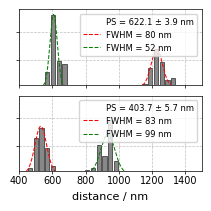

In [34]:
fig, axs = plotter.one_column_plot(npanels=2, ratios=[1,1], height=2, width=2)

dr, dc = np.diff(rows_1.astype(float)), np.diff(cols_1.astype(float))
distances_nm = np.concatenate([[0.], np.cumsum(np.sqrt(dr**2 + dc**2))]) * (69.0/oversampling)

bin_size_nm = 69.0 / 2  # e.g. 2 SR pixels per bar — adjust to taste                                                                                                     
                                                                                                                                                                          
bins = np.arange(distances_nm[0], distances_nm[-1] + bin_size_nm, bin_size_nm)
bin_counts, edges = np.histogram(distances_nm, bins=bins, weights=values_1)
bin_norm,   _     = np.histogram(distances_nm, bins=bins)            # pixels per bin
bin_means = np.where(bin_norm > 0, bin_counts / bin_norm, 0.0)       # mean intensity
bin_centres = (edges[:-1] + edges[1:]) / 2


axs[0].bar(bin_centres, bin_means, width=bin_size_nm * 0.75, color='#888', edgecolor='k', linewidth=0.4)
axs[0].set_xlim([400, 1500])

from scipy.optimize import curve_fit
from scipy.signal import find_peaks

def gaussian(x, A, mu, sigma):
  return A * np.exp(-(x - mu)**2 / (2 * sigma**2))

def double_gaussian(x, A1, mu1, s1, A2, mu2, s2, offset):
  return gaussian(x, A1, mu1, s1) + gaussian(x, A2, mu2, s2) + offset

# Auto-guess peak positions from the binned data
peaks, props = find_peaks(bin_means, distance=3, prominence=bin_means.max()*0.2)

if len(peaks) >= 2:
  p1, p2 = peaks[np.argsort(props['prominences'])[-2:]]   # two tallest
  p0 = [
      bin_means[p1], bin_centres[p1], bin_size_nm * 2,
      bin_means[p2], bin_centres[p2], bin_size_nm * 2,
      0.0,
  ]
  try:
      popt, pcov = curve_fit(double_gaussian, bin_centres, bin_means, p0=p0,
                             bounds=(0, np.inf), maxfev=5000)
      perr = np.sqrt(np.diag(pcov))

      x_fit = np.linspace(bin_centres[0], bin_centres[-1], 500)
      fwhm_label = fwhm(popt[[2, 5]])
      separation_nm = abs(popt[4] - popt[1])
      axs[0].plot(0, 0, alpha=0, label=f'PS = {separation_nm:.1f} ± 'f'{np.sqrt(perr[1]**2 + perr[4]**2):.1f} nm')
      axs[0].plot(x_fit, gaussian(x_fit, *popt[[0,1,2]]) + popt[6], 'r--', linewidth=0.75, label='FWHM = '+str(int(fwhm_label[0]))+' nm')
      axs[0].plot(x_fit, gaussian(x_fit, *popt[[3,4,5]]) + popt[6], 'g--', linewidth=0.75, label='FWHM = '+str(int(fwhm_label[1]))+' nm')

  except RuntimeError:
      print("Fit did not converge — adjust p0 or bin_size_nm")

axs[0].legend(loc='best', fontsize=6)
axs[0].set_xlabel('', fontsize=8)
axs[0].set_ylabel('', fontsize=8)
axs[0].set_yticklabels([])
axs[0].set_ylim([100, 2800])
axs[0].grid(lw=0.5, alpha=0.5, ls='--', color='gray')

dr, dc = np.diff(rows_2.astype(float)), np.diff(cols_2.astype(float))
distances_nm = np.concatenate([[0.], np.cumsum(np.sqrt(dr**2 + dc**2))]) * (69.0/oversampling)


#########
bins = np.arange(distances_nm[0], distances_nm[-1] + bin_size_nm, bin_size_nm)
bin_counts, edges = np.histogram(distances_nm, bins=bins, weights=values_2)
bin_norm,   _     = np.histogram(distances_nm, bins=bins)            # pixels per bin
bin_means = np.where(bin_norm > 0, bin_counts / bin_norm, 0.0)       # mean intensity
bin_centres = (edges[:-1] + edges[1:]) / 2


axs[1].bar(bin_centres, bin_means, width=bin_size_nm * 0.75, color='#888', edgecolor='k', linewidth=0.4)
axs[1].set_xlim([400, 1500])

# Auto-guess peak positions from the binned data
peaks, props = find_peaks(bin_means, distance=3, prominence=bin_means.max()*0.2)

if len(peaks) >= 2:
  p1, p2 = peaks[np.argsort(props['prominences'])[-2:]]   # two tallest
  p0 = [
      bin_means[p1], bin_centres[p1], bin_size_nm * 2,
      bin_means[p2], bin_centres[p2], bin_size_nm * 2,
      0.0,
  ]
  try:
      popt, pcov = curve_fit(double_gaussian, bin_centres, bin_means, p0=p0,
                             bounds=(0, np.inf), maxfev=5000)
      perr = np.sqrt(np.diag(pcov))

      x_fit = np.linspace(bin_centres[0], bin_centres[-1], 500)
      fwhm_label = fwhm(popt[[2, 5]])
      separation_nm = abs(popt[4] - popt[1])
      axs[1].plot(0, 0, alpha=0, label=f'PS = {separation_nm:.1f} ± 'f'{np.sqrt(perr[1]**2 + perr[4]**2):.1f} nm')
      axs[1].plot(x_fit, gaussian(x_fit, *popt[[0,1,2]]) + popt[6], 'r--', linewidth=0.75, label='FWHM = '+str(int(fwhm_label[0]))+' nm')
      axs[1].plot(x_fit, gaussian(x_fit, *popt[[3,4,5]]) + popt[6], 'g--', linewidth=0.75, label='FWHM = '+str(int(fwhm_label[1]))+' nm')

  except RuntimeError:
      print("Fit did not converge — adjust p0 or bin_size_nm")


axs[1].legend(loc='best', fontsize=6)
axs[1].set_xlabel('distance / nm', fontsize=8)
axs[1].set_ylabel('', fontsize=8)
axs[1].set_yticklabels([])
axs[1].set_ylim([100, 2800])
axs[1].grid(lw=0.5, alpha=0.5, ls='--', color='gray')
axs[0].set_xticklabels([])

plt.savefig("Superres_cutthroughs.svg", dpi=600, format="svg")
plt.show()

In [ ]:
from src.FRCFunctions import fire

In [ ]:
# --- parameters ---
pixel_size_nm = 69      # nm per camera pixel
zoom          = 8      # SR pixels per camera pixel → 6.9 nm SR pixels

# linked_fremoved, width, height already defined in the notebook

resolution_nm, frc_mean, res_hi_nm, res_lo_nm = fire(
    positions     = linked_fremoved,   # DataFrame with xc, yc, frame
    nx            = width,
    ny            = height,
    zoom          = zoom,
    n_blocks      = 50,                # temporal blocks per half-split (default)
    reps          = 20,                # independent repeats to average (default)
    pixel_size_nm = pixel_size_nm,
)

print(f"FIRE resolution: {resolution_nm:.1f} nm")
print(f"  upper bound (better): {res_hi_nm:.1f} nm")
print(f"  lower bound (worse):  {res_lo_nm:.1f} nm")


In [1]:
fig, ax = plotter.two_column_plot()

sz       = max(width, height) * zoom
sr_px_nm = pixel_size_nm / zoom        # nm per SR pixel

k   = np.arange(len(frc_mean))
q   = k / sz                           # cycles per SR pixel
q_nm = q / sr_px_nm                   # cycles per nm  (= 1 / d_nm)

# keep only below Nyquist
mask = (q > -0.05) & (q < 0.6)

# 1/7 crossing in cycles/nm
q_cross = 1.0 / resolution_nm         # cycles per nm at the FIRE value
q_hi    = 1.0 / res_hi_nm
q_lo    = 1.0 / res_lo_nm

ax = plotter.line_plot(ax, q_nm[mask], frc_mean[mask], label='FRC (mean)')
ax.axhline(1/7, color='gray', ls='--', lw=1, label='1/7 threshold')
ax.axvline(q_cross, color='crimson', ls='-', lw=1,
           label=f'FIRE = {resolution_nm:.0f} nm')
ax.axvspan(q_lo, q_hi, alpha=0.15, color='crimson', label='±1σ')
ax.set_xlabel(r'1 / spatial frequency (nm)', fontsize=8)
ax.set_ylabel('FRC', fontsize=8)
ax.set_ylim([0, 1.05])
ax.set_xscale('log')

tick_nm = [1000, 500, 200, 100, 50, 30]          # nm values to label
ax.set_xticks([1/d for d in tick_nm])

ax.set_xticklabels([f'{d} nm' for d in tick_nm])
ax.set_xlim([1/200, 1/15])
ax.legend(fontsize=7)
plt.tight_layout()
plt.savefig("FRC_HeLa.svg", dpi=600, format="svg")


NameError: name 'plotter' is not defined